In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from xgboost import XGBRegressor
import optuna
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
import matplotlib.dates as mdates
import shap
import joblib
import warnings
import os
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

def wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))

c:\Users\hardi\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Load Data

In [2]:
# 1. Load Data
df = pd.read_csv('data_for_forecast_revenue.csv')
df['periode'] = pd.to_datetime(df['periode'])

# 2. Pre-processing & Patching
df = df.dropna(subset=['lag_1w_revenue', 'lag_4w_revenue']).copy()

# 3. Strict Temporal Split (Chronological sorting before split)
df = df.sort_values(by=['periode']).reset_index(drop=True)

# Rule 1: Allowlist Features
target = 'target_revenue'
cat_features = ['soldto', 'regional', 'province_desc']
lag_features = [
    'lag_1w_revenue', 'lag_4w_revenue', 'rolling_4w_revenue_mean', 'rolling_4w_revenue_std', 
    'lag_1w_sellout', 'lag_1w_toko_aktif', 'lag_1w_sell_through_rate', 'rolling_4w_str_mean', 
    'lag_1w_avg_stock_toko', 'lag_1w_volume_sales', 'lag_1w_volume_order', 'lag_1w_n_toko_surveyed'
]
time_features = ['month', 'quarter', 'week_of_year', 'month_sin', 'month_cos', 'week_sin', 'week_cos']

allowlist_x = cat_features + lag_features + time_features

#### Encoding & Splitting

In [3]:
# Keep only the columns we need
keep_cols = ['periode', target] + allowlist_x
df = df[[c for c in keep_cols if c in df.columns]]

# Categorical Encoding
encoders = {}
for col in cat_features:
    if col in df.columns:
        le = LabelEncoder()
        df[col] = df[col].astype(str)
        df[col] = le.fit_transform(df[col])
        encoders[col] = le

# Split Index (80%)
split_idx = int(len(df) * 0.8)
train = df.iloc[:split_idx].copy()
test = df.iloc[split_idx:].copy()

actual_allowlist_x = [c for c in allowlist_x if c in df.columns]
X_train = train[actual_allowlist_x]
y_train = train[target]
X_test = test[actual_allowlist_x]
y_test = test[target]

print(f"Train Set: {X_train.shape[0]} rows | Test Set: {X_test.shape[0]} rows")

Train Set: 3719 rows | Test Set: 930 rows


#### Proses Tuning Model

In [4]:
# 4. Modeling & Optuna
print("Tuning LightGBM...")
def objective_lgb(trial):
    params = {
        'objective': 'tweedie',
        'n_estimators': trial.suggest_int('n_estimators', 50, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'num_leaves': trial.suggest_int('num_leaves', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'verbose': -1,
        'random_state': 42
    }
    model = lgb.LGBMRegressor(**params)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    return rmse

study_lgb = optuna.create_study(direction='minimize')
study_lgb.optimize(objective_lgb, n_trials=100)
best_lgb = lgb.LGBMRegressor(**study_lgb.best_params, verbose=-1, random_state=42)
best_lgb.fit(X_train, y_train)

Tuning LightGBM...


,boosting_type,'gbdt'
,num_leaves,53
,max_depth,4
,learning_rate,0.016091641587853173
,n_estimators,363
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [5]:
print("Tuning XGBoost...")
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'random_state': 42
    }
    model = XGBRegressor(**params)
    model.fit(X_train, y_train, verbose=False)
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    return rmse

study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(objective_xgb, n_trials=100)
best_xgb = XGBRegressor(**study_xgb.best_params, random_state=42)
best_xgb.fit(X_train, y_train, verbose=False)

Tuning XGBoost...


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.5192742983787288
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


#### Evaluasi Metrik

In [6]:
# Supply Chain Metrics & Evaluation
pred_lgb = best_lgb.predict(X_test)
pred_xgb = best_xgb.predict(X_test)
rmse_lgb = np.sqrt(mean_squared_error(y_test, pred_lgb))
rmse_xgb = np.sqrt(mean_squared_error(y_test, pred_xgb))

best_model = best_lgb if rmse_lgb < rmse_xgb else best_xgb
best_preds = pred_lgb if rmse_lgb < rmse_xgb else pred_xgb
model_name = "LightGBM" if rmse_lgb < rmse_xgb else "XGBoost"

print(f"\n[Case 1 - Block A] Selected Best Model: {model_name}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, best_preds)):.2f}")
print(f"MAE: {mean_absolute_error(y_test, best_preds):.2f}")
print(f"R-squared: {r2_score(y_test, best_preds):.4f}")

wape_score = wape(y_test, best_preds)
print(f"WAPE: {wape_score:.4f}")
forecast_accuracy = max(0, 1 - wape_score) * 100
print(f"Forecast Accuracy (Berdasarkan WAPE): {forecast_accuracy:.2f}%")
mape_score = mean_absolute_percentage_error(y_test, best_preds)
print(f"MAPE: {mape_score:.4f}")


[Case 1 - Block A] Selected Best Model: LightGBM
RMSE: 176011155.01
MAE: 136352604.95
R-squared: 0.0800
WAPE: 0.4928
Forecast Accuracy (Berdasarkan WAPE): 50.72%
MAPE: 1.1276



Top 10 Feature Importances:
                 Feature  Importance
          lag_4w_revenue    0.086240
  rolling_4w_revenue_std    0.086240
     lag_1w_volume_sales    0.081462
lag_1w_sell_through_rate    0.080506
 rolling_4w_revenue_mean    0.073579
     rolling_4w_str_mean    0.066890
                  soldto    0.064501
     lag_1w_volume_order    0.063784
           province_desc    0.060678
          lag_1w_revenue    0.058051


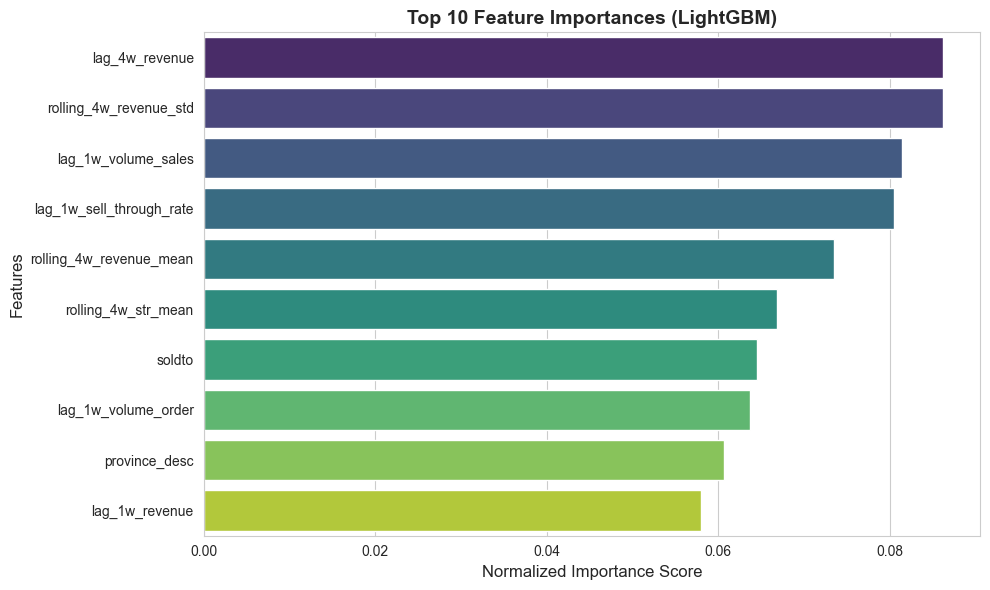

In [7]:
# Feature Importances
importances = best_model.feature_importances_
if np.sum(importances) > 0:
    importances = importances / np.sum(importances)
feat_imp = pd.DataFrame({'Feature': actual_allowlist_x, 'Importance': importances}).sort_values('Importance', ascending=False)
top_10_features = feat_imp.head(10)

print("\nTop 10 Feature Importances:")
print(top_10_features.to_string(index=False))

if top_10_features.iloc[0]['Importance'] > 0.8:
    print(f"\nWARNING: Feature '{top_10_features.iloc[0]['Feature']}' holds >80% importance ({top_10_features.iloc[0]['Importance']:.2%}!). Potential Target Leakage!")

# Set default seaborn style
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top_10_features, palette='viridis')
plt.title(f'Top 10 Feature Importances ({model_name})', fontsize=14, fontweight='bold')
plt.xlabel('Normalized Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

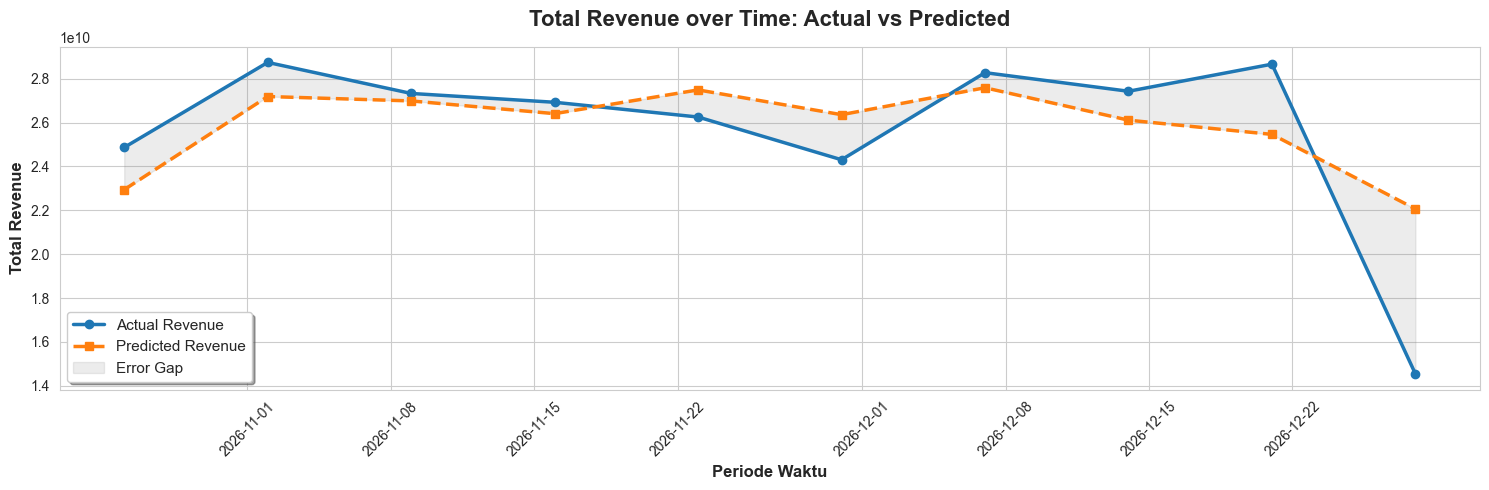

In [8]:
# Visualisasi Time-Series
test['predicted_revenue'] = best_preds
time_series_eval = test.groupby('periode')[['target_revenue', 'predicted_revenue']].sum().reset_index()

plt.figure(figsize=(15, 5))
plt.plot(time_series_eval['periode'], time_series_eval['target_revenue'], 
         label='Actual Revenue', marker='o', color='#1f77b4', linewidth=2.5, markersize=6)
plt.plot(time_series_eval['periode'], time_series_eval['predicted_revenue'], 
         label='Predicted Revenue', marker='s', color='#ff7f0e', linewidth=2.5, linestyle='--', markersize=6)
plt.fill_between(time_series_eval['periode'], 
                 time_series_eval['target_revenue'], 
                 time_series_eval['predicted_revenue'], 
                 color='gray', alpha=0.15, label='Error Gap')

plt.title('Total Revenue over Time: Actual vs Predicted', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Periode Waktu', fontsize=12, fontweight='bold')
plt.ylabel('Total Revenue', fontsize=12, fontweight='bold')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)
plt.legend(loc='best', frameon=True, shadow=True, fontsize=11)
plt.tight_layout()
plt.show()


Calculating SHAP values...


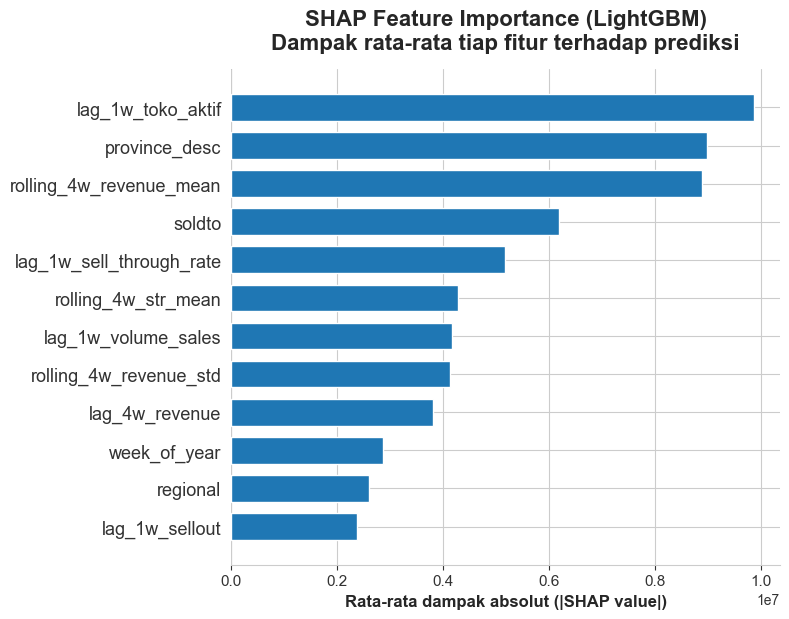

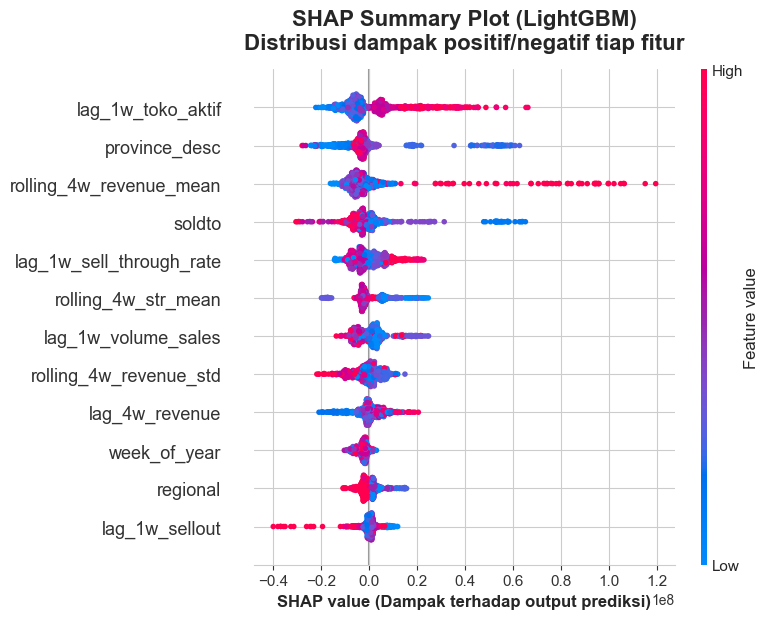

In [9]:
# Visualisasi SHAP
print("\nCalculating SHAP values...")
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(14, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False, color="#1f77b4", max_display=12)
plt.title(f"SHAP Feature Importance ({model_name})\nDampak rata-rata tiap fitur terhadap prediksi", 
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Rata-rata dampak absolut (|SHAP value|)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
shap.summary_plot(shap_values, X_test, show=False, max_display=12)
plt.title(f"SHAP Summary Plot ({model_name})\nDistribusi dampak positif/negatif tiap fitur", 
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel("SHAP value (Dampak terhadap output prediksi)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

plt.rcdefaults()

In [10]:
# Executive Roll-up
if 'province_desc' in encoders:
    test['province_desc_dec'] = encoders['province_desc'].inverse_transform(test['province_desc'])
else:
    test['province_desc_dec'] = 'UNKNOWN'
    
rollup = test.groupby(['periode', 'province_desc_dec'])[['target_revenue', 'predicted_revenue']].sum().reset_index()

# Menambahkan kolom Persentase Meleset (Error Percentage)
# Formula: |Aktual - Prediksi| / Aktual * 100
rollup['error_percentage'] = np.where(
    rollup['target_revenue'] == 0, 
    0, # Jika aktual = 0, anggap persentase error 0 agar tidak error (divide-by-zero)
    (np.abs(rollup['target_revenue'] - rollup['predicted_revenue']) / rollup['target_revenue']) * 100
)

# Fungsi format Nominal
def format_nominal(val):
    return f"Rp {val:,.0f}".replace(",", ".")

# Fungsi format Persentase
def format_percent(val):
    return f"{val:.2f}%"

# Daftarkan formatter ke masing-masing kolom
formatters = {
    'target_revenue': format_nominal,
    'predicted_revenue': format_nominal,
    'error_percentage': format_percent
}

print("\nExecutive Roll-Up (Head 20):")
print(rollup.head(20).to_string(index=False, formatters=formatters))



Executive Roll-Up (Head 20):
   periode         province_desc_dec   target_revenue predicted_revenue error_percentage
2026-10-26                      ACEH   Rp 451.727.645    Rp 507.917.644           12.44%
2026-10-26                      BALI   Rp 604.828.999    Rp 767.904.626           26.96%
2026-10-26                    BANTEN   Rp 110.931.980    Rp 451.407.790          306.92%
2026-10-26                  BENGKULU Rp 1.068.060.077    Rp 748.931.061           29.88%
2026-10-26             DI YOGYAKARTA   Rp 290.742.649    Rp 251.065.083           13.65%
2026-10-26               DKI JAKARTA   Rp 428.204.780    Rp 495.089.544           15.62%
2026-10-26                 GORONTALO   Rp 963.252.199    Rp 713.348.524           25.94%
2026-10-26                     JAMBI Rp 1.152.903.544  Rp 1.629.329.526           41.32%
2026-10-26                JAWA BARAT   Rp 586.490.259    Rp 548.186.256            6.53%
2026-10-26               JAWA TENGAH Rp 1.996.854.113  Rp 1.184.513.870         

In [11]:
joblib.dump(encoders, 'models/encoders_revenue.pkl')
print("Preprocessing encoders berhasil disimpan ke 'encoders_revenue.pkl'")

joblib.dump(best_model, 'models/best_revenue_model.pkl')
print(f"Model terbaik ({model_name}) berhasil disimpan ke 'best_revenue_model.pkl'")

Preprocessing encoders berhasil disimpan ke 'encoders_revenue.pkl'
Model terbaik (LightGBM) berhasil disimpan ke 'best_revenue_model.pkl'
